## Expérimentation de modèles

In [8]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.experimental import enable_halving_search_cv
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import (
    Lasso, LassoCV,
    Ridge, LinearRegression
)
from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    GridSearchCV,
    learning_curve,
    HalvingGridSearchCV
)
from sklearn.metrics import mean_squared_error, median_absolute_error, r2_score, get_scorer_names

In [9]:
train_data = pd.read_csv("../data/processed_dataset.csv")
test_data = pd.read_parquet("../data/test_data.parquet")

X_train = train_data.drop(
    ["LoyerMensuel_Log1", "LoyerMensuel_BIF", "IdentifiantMaison"],
    axis=1).select_dtypes(include=["number"])
y_train = train_data["LoyerMensuel_Log1"]

print(X_train)

     Chambres  Superficie_m2  DistanceRoute_m  AgeMaison  Salon_Bin  \
0         1.0      -1.592856         0.003290   0.040121          1   
1         4.0       0.699619         0.692082   0.305894          1   
2         4.0       0.216992        -1.084277   0.394485          1   
3         6.0       1.182245         1.223782  -1.554515          1   
4         3.0      -0.037727        -1.507220   1.280394          1   
..        ...            ...              ...        ...        ...   
377       4.0       0.243805         0.716250  -0.491424          1   
378       6.0       0.082929         1.163361   1.280394          1   
379       5.0       0.780056         1.682977  -0.314243          1   
380       6.0       1.638059        -1.567640   0.926030          1   
381       6.0       1.436964         0.982100   1.014621          1   

     SalleDeBainInterieure_Bin  Parking_Bin  Meuble_Bin  Jardin_Bin  \
0                            1            0           0           0   
1    

### Transformation de données de test

In [10]:
# cols_a_scaler = ["Superficie_m2", "DistanceRoute_m", "AgeMaison"]

# for col in ['Salon', 'SalleDeBainInterieure', 'Parking', 'Meuble', 'Jardin']:
#     test_data[col + "_Bin"] = test_data[col].map({"Oui": 1, "Non": 0}).fillna(0).astype(int)

# scaler = joblib.load("scaler.joblib")
# print(scaler.mean_)
# scaler_values = scaler.transform(test_data[cols_a_scaler])
# print(scaler_values)
# scaled_df = pd.DataFrame(scaler_values, columns=cols_a_scaler, index=test_data.index)
# test_data[cols_a_scaler] = scaled_df

# neighbourhood_encoder = joblib.load("neighbourhood_encoder.joblib")
# test_data["Quartier_Target"] = neighbourhood_encoder.transform(test_data[["Quartier"]])[:, 0]

# test_data["LoyerMensuel_Log1"] = np.log1p(test_data["LoyerMensuel_BIF"])

# Création de variables utiles pour le test
# cols_confort = ['Salon_Bin', 'SalleDeBainInterieure_Bin', 'Parking_Bin', 'Meuble_Bin', 'Jardin_Bin']
# test_data['Indicateur_Confort'] = test_data[cols_confort].sum(axis=1)

# test_data['Chambres_par_Superficie'] = test_data['Chambres'] / (test_data['Superficie_m2'] + 0.1)

# Séparation de X_test et y_test
X_test = test_data.drop(
    ["LoyerMensuel_Log1", "LoyerMensuel_BIF", "IdentifiantMaison"],
    axis=1).select_dtypes(include=["number"])
y_test = test_data["LoyerMensuel_Log1"]

X_test

,Chambres,Superficie_m2,DistanceRoute_m,AgeMaison,Salon_Bin,SalleDeBainInterieure_Bin,Parking_Bin,Meuble_Bin,Jardin_Bin,Quartier_Target
0,1.0,-1.324731,1.767565,-1.377334,1,1,1,0,0,0.010428
1,2.0,-0.493541,-1.035941,1.457576,1,1,1,0,0,0.001998
2,5.0,1.262683,-1.458883,0.217303,1,1,0,0,1,0.010428
3,4.0,1.128620,-0.129635,-1.465925,1,1,0,0,0,0.002163
4,1.0,-1.700107,-0.093383,0.660257,0,1,1,0,0,0.002146
...,...,...,...,...,...,...,...,...,...,...
123,4.0,0.578962,0.389980,0.571666,1,1,1,0,1,0.002029
124,5.0,0.538743,-0.322980,-0.668606,1,1,1,0,1,0.001998
125,6.0,1.195651,-0.480073,0.837439,1,1,1,0,1,0.002014
126,4.0,0.176773,0.716250,-0.402834,1,1,0,1,1,0.002163


In [11]:
def formated_time(second):
    m, s = divmod(second, 60)

    if m > 0:
         f"{int(m)} min {s:.4f} secondes"
    else:
        return f"{s:.4f} secondes"

scoring = ["neg_mean_squared_error", "neg_median_absolute_error", "neg_root_mean_squared_error", "r2"]

In [26]:
def _learning_curve(model, model_name, X=X_train, y=y_train):
    metrics = {
        "RMSE": {
            "scoring": "neg_mean_squared_error",
            "transform": lambda x: np.sqrt(-x),
            "ylabel": "RMSE",
        },
        "MAE": {
            "scoring": "neg_mean_absolute_error",
            "transform": lambda x: -x,
            "ylabel": "MAE",
        },
        "R2": {
            "scoring": "r2",
            "transform": lambda x: x,
            "ylabel": "r2_scores",
        },
    }

    fig, axes = plt.subplots(3, 3, figsize=(17, 12))
    axes_flat = axes.flatten()

    for i, (metric_name, metric_info) in enumerate(metrics.items()):
        ax = axes_flat[i]

        train_sizes, train_scores, test_scores = learning_curve(
            estimator=model,
            X=X,
            y=y,
            train_sizes=np.linspace(0.1, 1.0, 10),
            cv=10,
            scoring=metric_info["scoring"],
            n_jobs=-1,
            random_state=40,
        )

        train_scores_trans = metric_info["transform"](train_scores)
        test_scores_trans = metric_info["transform"](test_scores)

        train_mean = train_scores_trans.mean(axis=1)
        train_std = train_scores_trans.std(axis=1)
        test_mean = test_scores_trans.mean(axis=1)
        test_std = test_scores_trans.std(axis=1)

        ax.plot(
            train_sizes,
            train_mean,
            "o-",
            color="red",
            label="Score entraînement",
        )
        ax.fill_between(
            train_sizes,
            train_mean - train_std,
            train_mean + train_std,
            alpha=0.1,
            color="red",
        )

        ax.plot(
            train_sizes,
            test_mean,
            "o-",
            color="blue",
            label="Score validation",
        )
        ax.fill_between(
            train_sizes,
            test_mean - test_std,
            test_mean + test_std,
            alpha=0.1,
            color="blue",
        )

        ax.set_title(f"{metric_name}")
        ax.set_xlabel("Exemples d'entraînement")
        ax.set_ylabel(metric_info["ylabel"])
        ax.legend(loc="best")
        ax.grid(True)

    model.fit(X, y)
    y_pred = model.predict(X)
    residuals = y - y_pred

    ax_act_pred = axes_flat[3]
    ax_act_pred.scatter(y, y_pred, alpha=0.5, color="green")

    min_val = min(min(y), min(y_pred))
    max_val = max(max(y), max(y_pred))
    ax_act_pred.plot(
        [min_val, max_val],
        [min_val, max_val],
        "r--",
        lw=2,
        label="Parfait (y=x)",
    )

    ax_act_pred.set_title("Actual vs Predicted")
    ax_act_pred.set_xlabel("Valeurs Réelles (y)")
    ax_act_pred.set_ylabel("Valeurs Prédites (y_pred)")
    ax_act_pred.legend(loc="best")
    ax_act_pred.grid(True)

    ax_res = axes_flat[4]
    ax_res.scatter(y_pred, residuals, alpha=0.5, color="purple")
    ax_res.axhline(y=0, color="red", linestyle="--", lw=2)

    ax_res.set_title("Residual Plot")
    ax_res.set_xlabel("Valeurs Prédites (y_pred)")
    ax_res.set_ylabel("Résidus (y - y_pred)")
    ax_res.grid(True)

    for j in range(5, 9):
        fig.delaxes(axes_flat[j])

    fig.suptitle(
        f"Évaluation du Modèle - {model_name}", fontsize=16, y=1.02
    )
    plt.tight_layout()
    plt.show()

### Modèle de Régression Linéaire

--- Analyse Finale : LinearRegression (Modèle non-itératif) ---
Loss Finale (Train): 0.1828
Loss Finale (Val): 0.1724
Note : Ce modèle ne supporte pas l'affichage itératif (courbe).


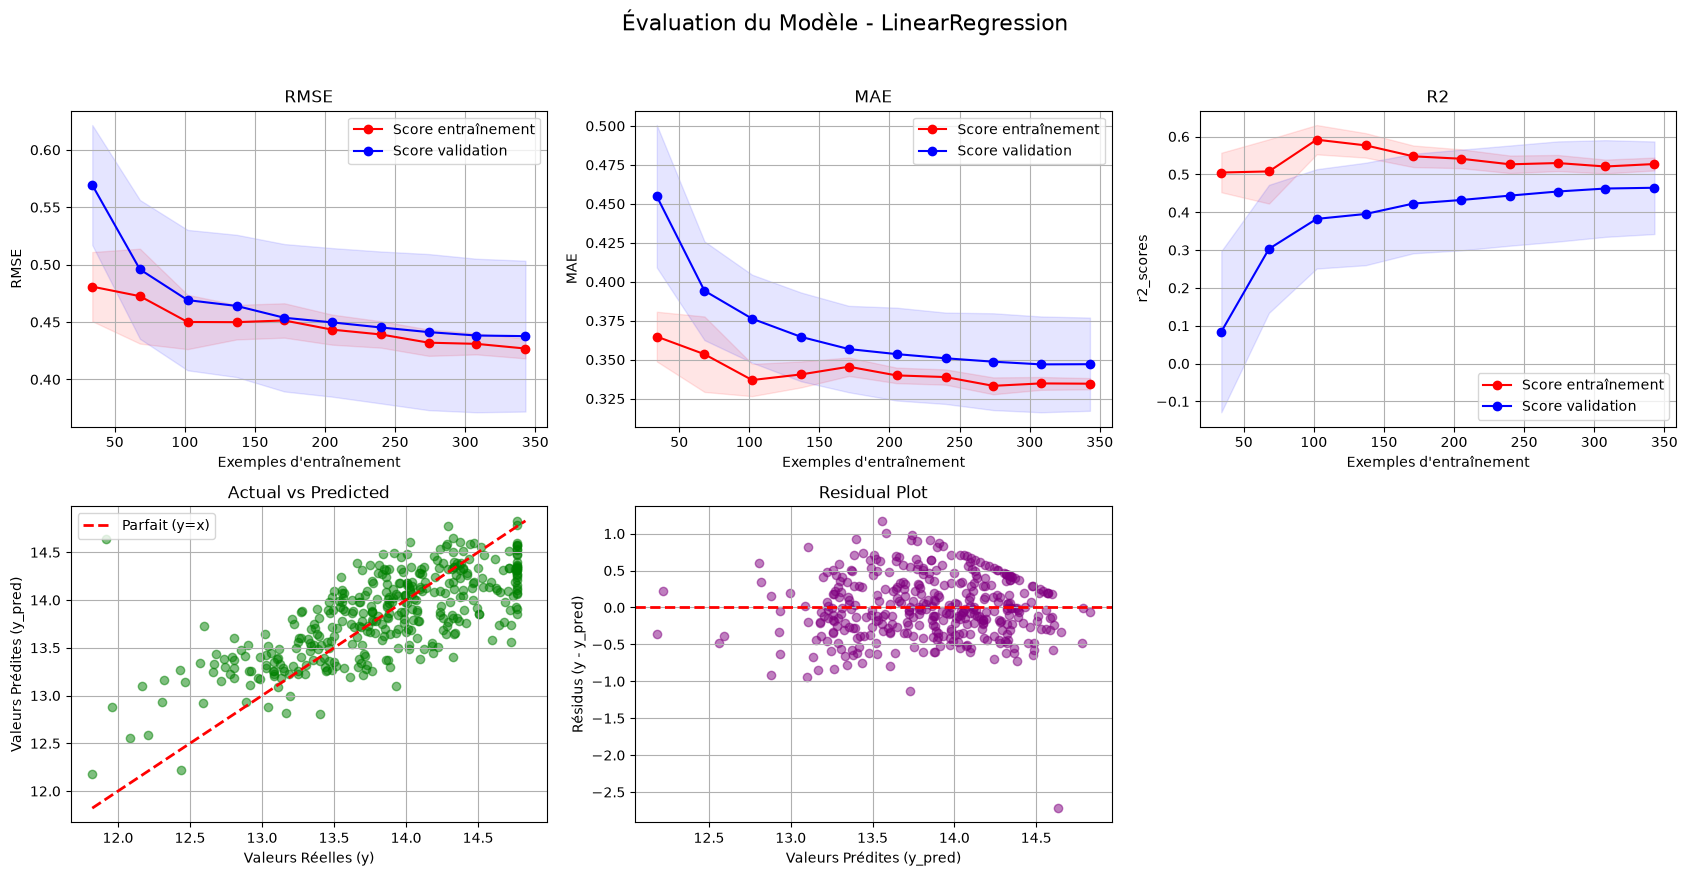

In [33]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)
y_predict = linear_model.predict(X_test)
score = r2_score(y_test, y_predict)

# linear_scores = cross_validate(linear_model, X_train, y_train, scoring=scoring)

# print(f"Fit Time : {linear_scores["fit_time"]}")
# print()
# print(f"Score Time : {linear_scores["score_time"]}")
# print()
# print(f"Test Neg Median Abosulte Error : {linear_scores["test_neg_median_absolute_error"]}")
# print()
# print(f"Test Neg Mean Squared Error : {linear_scores["test_neg_mean_squared_error"]}")
# print()
# print(f"Test R2 : {linear_scores["test_r2"]}")

# print(f"r2 final score : {score:.4f}")

plot_learning_curves(linear_model, X_train, y_train, X_test, y_test, "LinearRegression")

_learning_curve(
    model=linear_model,
    model_name="LinearRegression",
)

### Modèle Lasso

0.6465586349325605


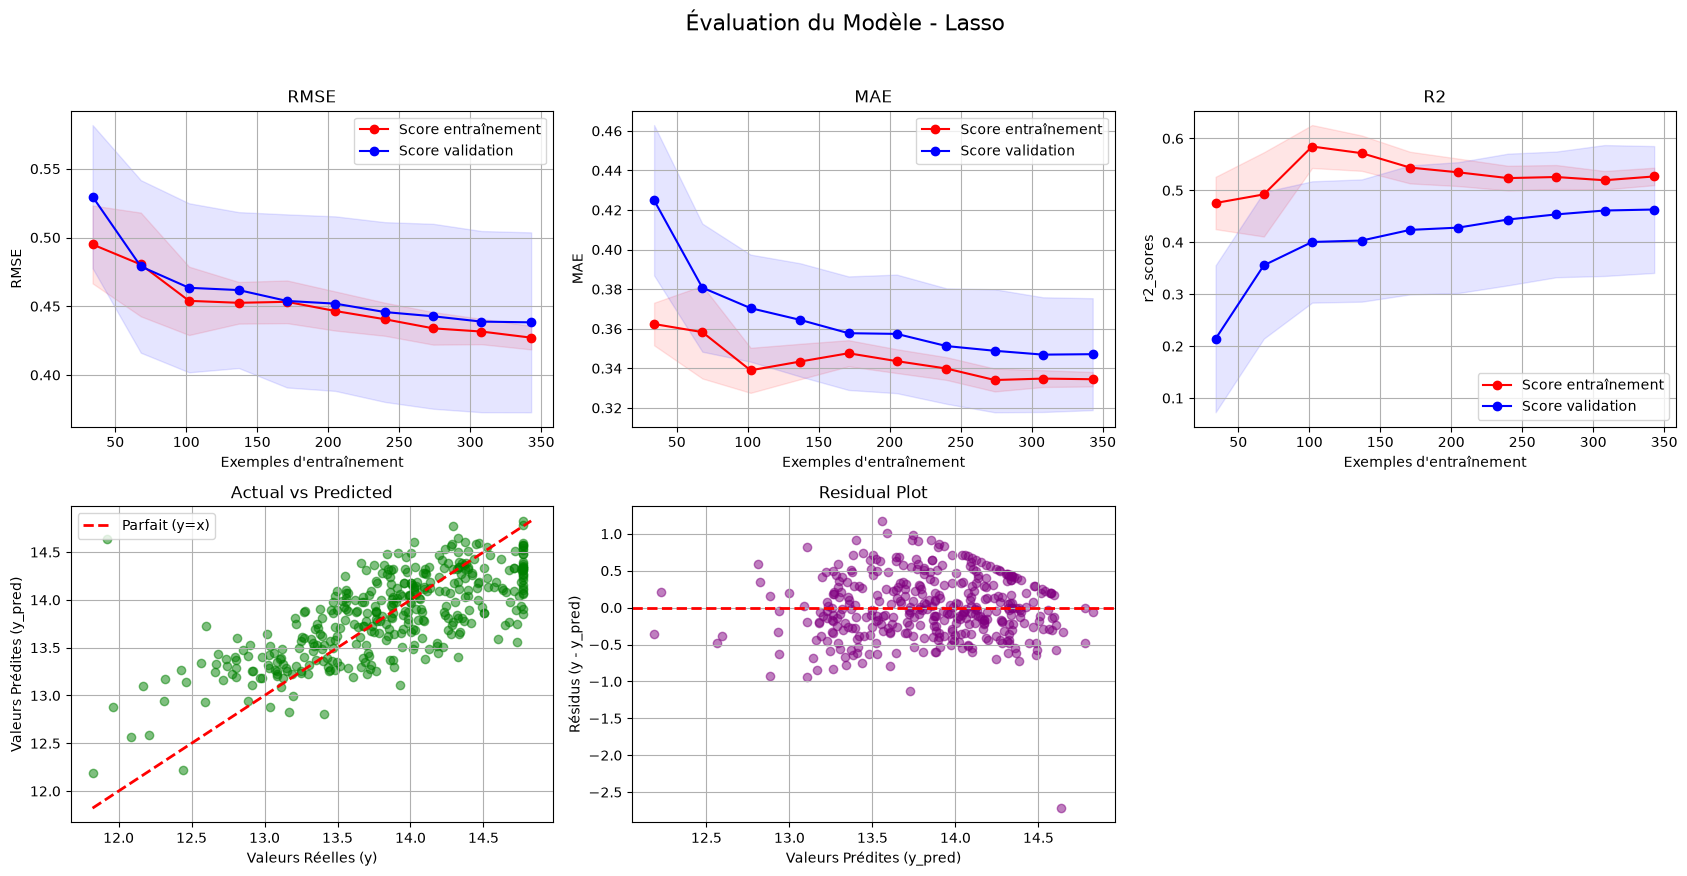

In [16]:
# lasso_model = make_pipeline(StandardScaler(), LassoCV(cv=10, random_state=40))
lasson_model = Lasso()
lasso_model.fit(X_train, y_train)
y_predict = lasso_model.predict(X_test)

# lasso_cv = lasso_model[-1]

# alphas = lasso_cv.alphas_
# mse_mean = lasso_cv.mse_path_.mean(axis=1)
# mse_std = lasso_cv.mse_path_.std(axis=1)
# alpha_best = lasso_cv.alpha_

# print(alpha_best)

# plt.figure(figsize=(10, 6))

# plt.semilogx(alphas, lasso_cv.mse_path_, ":", alpha=0.3, label="MSE par pli")
# plt.semilogx(alphas, mse_mean, "b-", linewidth=2, label="MSE mean")

# plt.semilogx(alphas, mse_mean + mse_std, "b--", alpha=0.5)
# plt.semilogx(alphas, mse_mean + mse_std, "b--", alpha=0.5)

# plt.axvline(alpha_best, color="r", linestyle="--", label=f"Meilleur alpha : {alpha_best:.4f}")

# plt.xlabel(r"$\alpha$ Paramètres de régularisation")
# plt.ylabel("Erreur Quadratique Moyenne")
# plt.title("Sélection du modèle Lasso par validation croisée")
# plt.legend()

# plt.grid(True, which="both", ls="-", alpha=0.4)
# plt.tight_layout()
# plt.show()

print(r2_score(y_test, y_predict))

_learning_curve(
    model=lasso_model,
    model_name="Lasso",
)

### Ridget Model

Fit Time : [0.01133108 0.0109334  0.00687981 0.00598955 0.00600743]

Score Time : [0.01244283 0.00978088 0.01079988 0.0075388  0.00448489]

Test Neg MSE : [-0.29862344 -0.23464307 -0.20730572 -0.18692377 -0.17880899]

Test Neg  MAE : [-0.31292057 -0.3732726  -0.35650725 -0.31659814 -0.35692728]

Test Neg SMSE : [-0.54646449 -0.4843997  -0.45530838 -0.43234681 -0.42285812]

Test R2 : [0.34536096 0.5238469  0.34886588 0.36874043 0.47604367]
r2 score : 0.5458727499101903


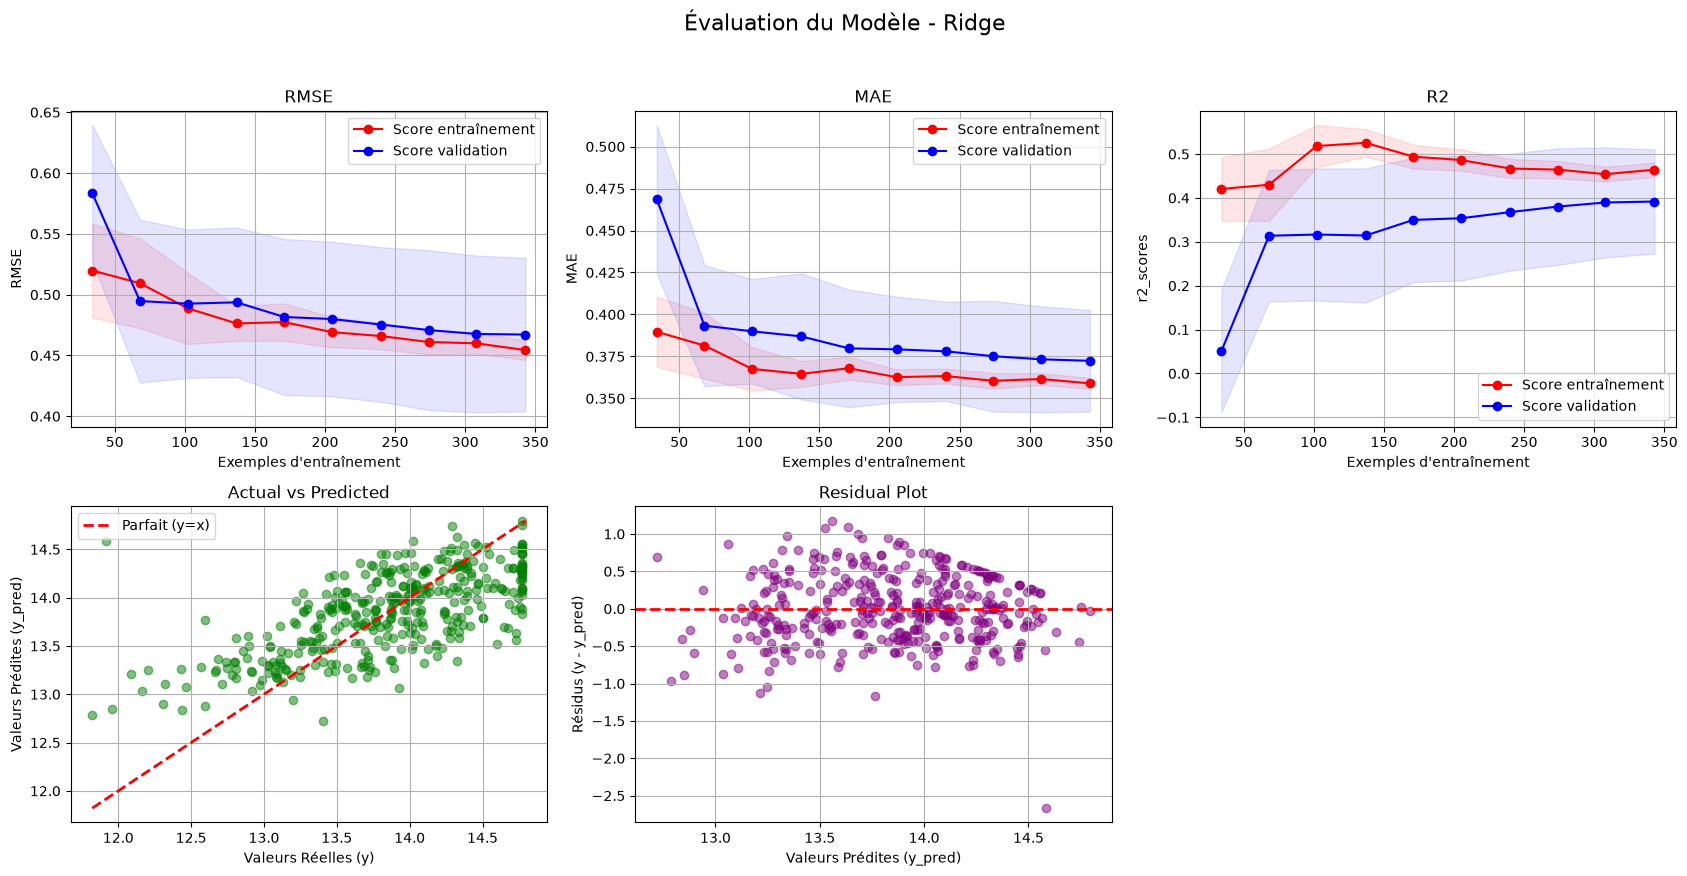

In [15]:
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train, y_train)
y_predict = ridge_model.predict(X_test)

ridge_scores = cross_validate(ridge_model, X_train, y_train, scoring=scoring)

print(f"Fit Time : {ridge_scores["fit_time"]}")
print()
print(f"Score Time : {ridge_scores["score_time"]}")
print()
print(f"Test Neg MSE : {ridge_scores["test_neg_mean_squared_error"]}")
print()
print(f"Test Neg  MAE : {ridge_scores["test_neg_median_absolute_error"]}")
print()
print(f"Test Neg SMSE : {ridge_scores["test_neg_root_mean_squared_error"]}")
print()
print(f"Test R2 : {ridge_scores["test_r2"]}")

print(f"r2 score : {r2_score(y_test, y_predict)}")

_learning_curve(
    model=ridge_model,
    model_name="Ridge",
)

### Arbres de décision

Fit Time : [0.00987816 0.00818539 0.00825429 0.00869942 0.01014161]

Score Time : [0.01019311 0.00922465 0.00914478 0.0097909  0.01596117]

Test Neg MSE : [-0.34927242 -0.19727496 -0.22019736 -0.21253189 -0.26444394]

Test Neg  MAE : [-0.30006272 -0.25023537 -0.27006084 -0.29411193 -0.29436472]

Test Neg SMSE : [-0.59099274 -0.44415645 -0.46925192 -0.46101181 -0.51424113]

Test R2 : [0.23432883 0.59967673 0.30837404 0.28225934 0.22511125]
r2 score : 0.6274956975816454


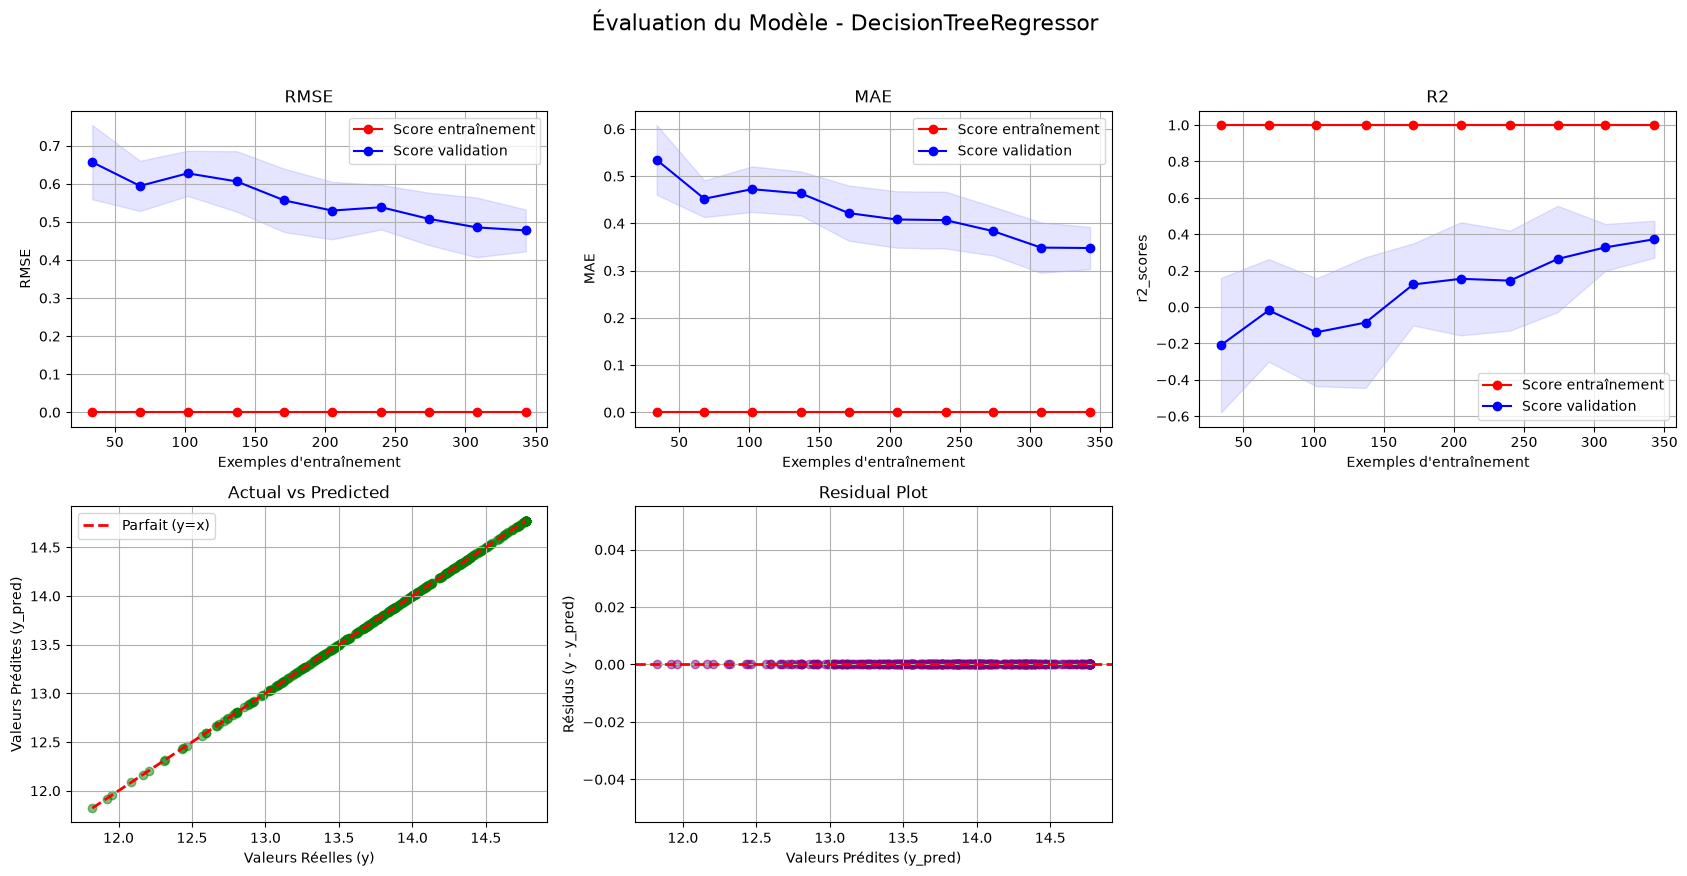

In [17]:
tree_model = DecisionTreeRegressor()
tree_model.fit(X_train, y_train)
y_predict = tree_model.predict(X_test)

tree_scores = cross_validate(tree_model, X_train, y_train, scoring=scoring)

print(f"Fit Time : {tree_scores["fit_time"]}")
print()
print(f"Score Time : {tree_scores["score_time"]}")
print()
print(f"Test Neg MSE : {tree_scores["test_neg_mean_squared_error"]}")
print()
print(f"Test Neg  MAE : {tree_scores["test_neg_median_absolute_error"]}")
print()
print(f"Test Neg SMSE : {tree_scores["test_neg_root_mean_squared_error"]}")
print()
print(f"Test R2 : {tree_scores["test_r2"]}")

print(f"r2 score : {r2_score(y_test, y_predict)}")

_learning_curve(
    model=tree_model,
    model_name="DecisionTreeRegressor",
)

### Modèle de Fôrets Aléatoire

Fit Time : [0.24059844 0.23856997 0.25111794 0.23324919 0.24732113]

Score Time : [0.0181632  0.02435565 0.0207479  0.01791072 0.01832366]

Test Neg MSE : [-0.20553029 -0.15166829 -0.10490491 -0.10342466 -0.11858768]

Test Neg  MAE : [-0.22678683 -0.25132078 -0.21564701 -0.2187767  -0.26620016]

Test Neg SMSE : [-0.45335448 -0.38944613 -0.32389028 -0.32159705 -0.34436562]

Test R2 : [0.54943875 0.69222477 0.67050032 0.65072494 0.65250761]
r2 score : 0.762416410832514


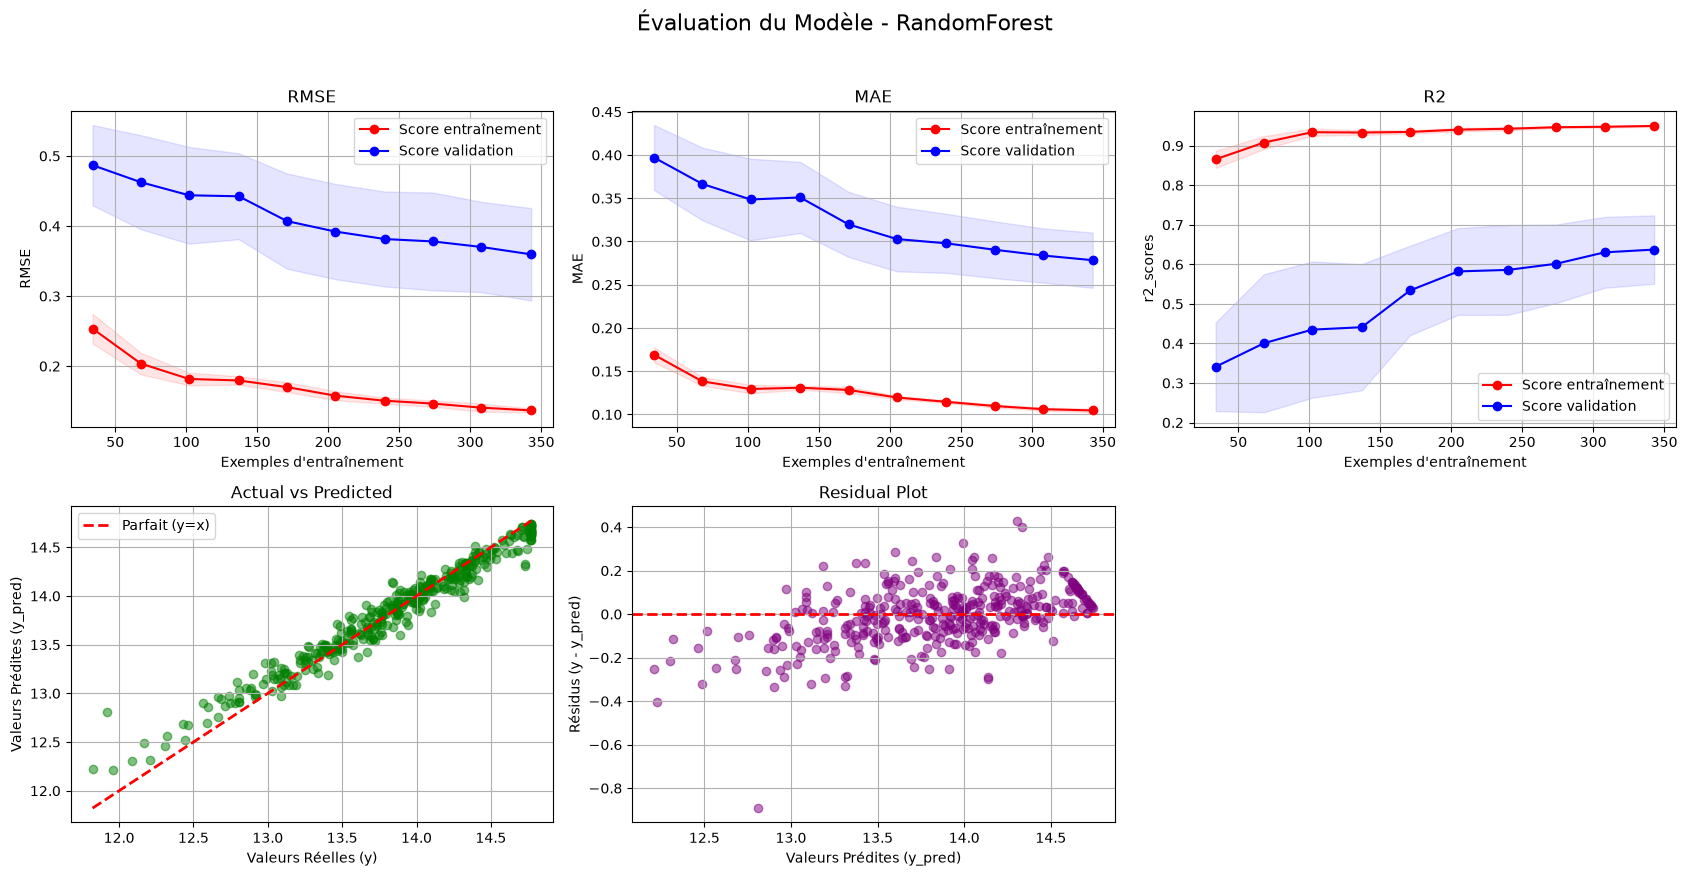

In [18]:
random_model = RandomForestRegressor()
random_model.fit(X_train, y_train)
y_predict = random_model.predict(X_test)

random_scores = cross_validate(random_model, X_train, y_train, scoring=scoring)

print(f"Fit Time : {random_scores["fit_time"]}")
print()
print(f"Score Time : {random_scores["score_time"]}")
print()
print(f"Test Neg MSE : {random_scores["test_neg_mean_squared_error"]}")
print()
print(f"Test Neg  MAE : {random_scores["test_neg_median_absolute_error"]}")
print()
print(f"Test Neg SMSE : {random_scores["test_neg_root_mean_squared_error"]}")
print()
print(f"Test R2 : {random_scores["test_r2"]}")

print(f"r2 score : {r2_score(y_test, y_predict)}")

_learning_curve(
    model=random_model,
    model_name="RandomForest",
)

### Modèle de Gradient Boosting

Loss finale (Train): 0.0000
Loss finale (Val): 0.0799
Meilleure itération (min val loss): 104 avec une loss de 0.0797


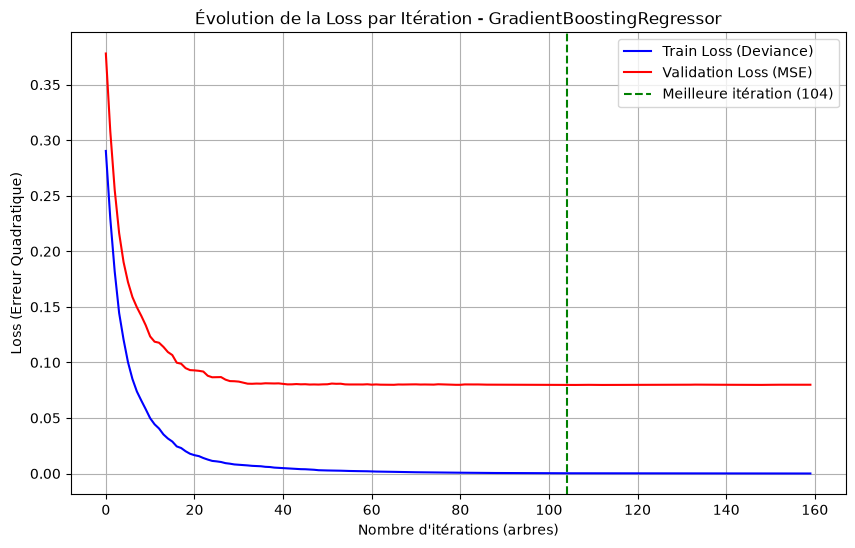

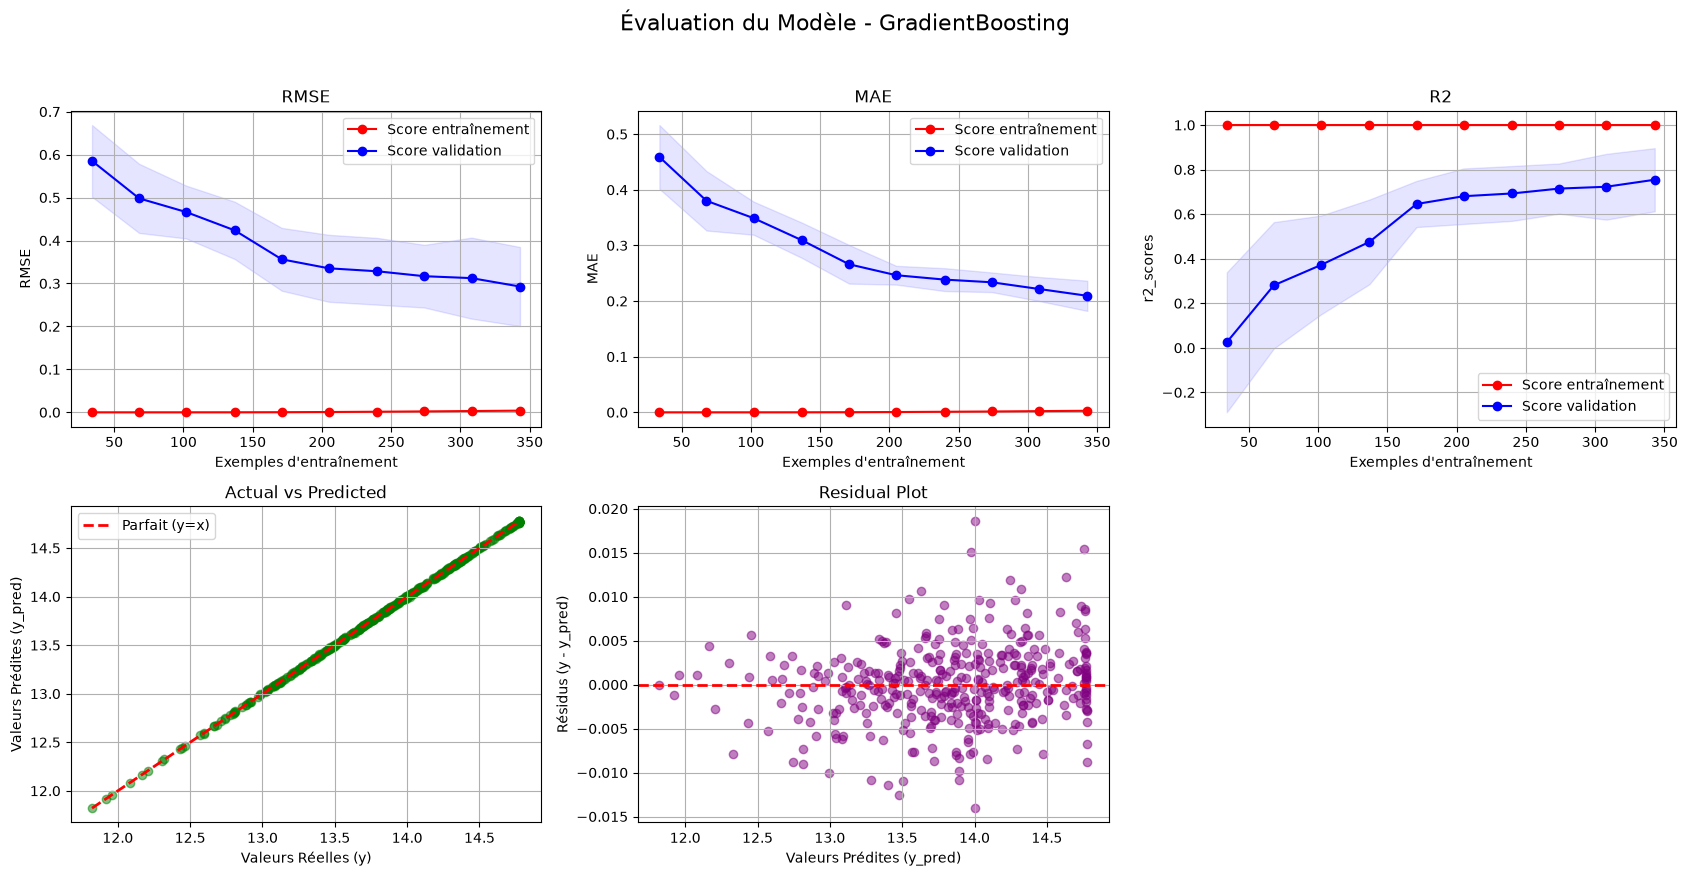

In [34]:
param_grid = {
    "n_estimators": np.linspace(50, 500, 5, dtype=int).tolist(),
    "learning_rate": np.logspace(-5, -1, 5).tolist(),
    "max_depth": np.linspace(1, 20, 4, dtype=int).tolist(),
    "subsample": np.linspace(0.5, 1.0, 4).tolist()
}

boosting_model = GradientBoostingRegressor(
    learning_rate=0.2,
    n_estimators=160,
    max_depth=5,
    random_state=42
)

boosting_model.fit(X_train, y_train)
y_predict = boosting_model.predict(X_test)

# search = HalvingGridSearchCV(
#     estimator=boosting_model,
#     param_grid=param_grid,
#     factor=2,
#     aggressive_elimination=True,
#     cv=5,
#     scoring="neg_mean_squared_error",
#     n_jobs=-1,
#     random_state=42
# )

# search.fit(X_train, y_train)

# print(search.best_score_)
# print(search.best_params_)
# print(search.best_estimator_)

# print(f"r2_Score : {r2_score(y_test, y_predict)}")

train_loss = boosting_model.train_score_

val_loss = []
for y_pred in boosting_model.staged_predict(X_test):
    score = mean_squared_error(y_test, y_pred)
    val_loss.append(score)

val_loss = np.array(val_loss)
iterations = np.arange(len(train_loss))

print(f"Loss finale (Train): {train_loss[-1]:.4f}")
print(f"Loss finale (Val): {val_loss[-1]:.4f}")

best_iter = np.argmin(val_loss)
print(f"Meilleure itération (min val loss): {best_iter} avec une loss de {val_loss[best_iter]:.4f}")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(iterations, train_loss, 'b-', label='Train Loss (Deviance)')
plt.plot(iterations, val_loss, 'r-', label='Validation Loss (MSE)')
plt.axvline(x=best_iter, color='green', linestyle='--', label=f'Meilleure itération ({best_iter})')
plt.xlabel('Nombre d\'itérations (arbres)')
plt.ylabel('Loss (Erreur Quadratique)')
plt.title('Évolution de la Loss par Itération - GradientBoostingRegressor')
plt.legend()
plt.grid(True)
plt.show()

_learning_curve(
    model=boosting_model,
    model_name="GradientBoosting",
)